# Explainability dei modelli

Questo notebook usa le funzioni definite in `utils/explainability.py` per generare spiegazioni LIME e SHAP dove applicabile.

L'analisi e divisa in tre blocchi separati:
- embedding testuali da 64 dimensioni
- embedding testuali da 128 dimensioni
- graph features

In [ ]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from utils.explainability import lime_explainer, shap_tree_explainer

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
EXPLANATION_SAMPLE_SIZE = 5_000


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "utils").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Project root non trovato: mancano le cartelle utils/ e data/.")


PROJECT_ROOT = find_project_root()
TEXTUAL_FEATURES_PATH = PROJECT_ROOT / "data" / "textual_features"
GRAPH_FEATURES_PATH = PROJECT_ROOT / "data" / "graph_features"
INITIAL_FEATURES_PATH = PROJECT_ROOT / "data" / "initial_features"
MODELS_ROOT = PROJECT_ROOT / "MODELZOO"

TEXTUAL_64_PATH = TEXTUAL_FEATURES_PATH / "textual_embeddings_64.parquet"
TEXTUAL_128_PATH = TEXTUAL_FEATURES_PATH / "textual_embeddings_128.parquet"

MODEL_DIRS = {
    "embedding_64": MODELS_ROOT / "textual_embeddings_64",
    "embedding_128": MODELS_ROOT / "textual_embeddings_128",
    "graph_features": MODELS_ROOT / "graph_features",
    "initial_features": MODELS_ROOT / "initial_features"
}

print(f"Project root: {PROJECT_ROOT}")
print(f"Textual features: {TEXTUAL_FEATURES_PATH}")
print(f"Graph features: {GRAPH_FEATURES_PATH}")
print(f"Initial features: {INITIAL_FEATURES_PATH}")
print(f"Models: {MODELS_ROOT}")

Project root: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1
Textual features: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/textual_features
Graph features: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/data/graph_features
Models: /home/tommaso/Documenti/SUPSI/BACHELOR/3_anno_bech/primaverile/M-P6203E-DataProjects-Hackaton3_P1/MODELZOO


In [ ]:
def load_all_models(models_dir: Path) -> dict[str, object]:
    """Loads all .pkl/.joblib models present in a folder."""
    if not models_dir.exists():
        print(f"Models folder not found: {models_dir}")
        return {}

    model_files = sorted(
        p for p in models_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in {".pkl", ".joblib"}
    )

    models = {}
    for model_path in model_files:
        try:
            models[model_path.stem] = joblib.load(model_path)
        except Exception as exc:
            print(f"Unable to load {model_path.name}: {exc}")

    print(f"Models loaded from {models_dir.name}: {len(models)}")
    for name in models:
        print(f" - {name}")
    return models


def split_train_test(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    if "split" in df.columns:
        split = df["split"].astype(str).str.lower()
        train_df = df[split.isin(["train", "training"])].copy()
        test_df = df[split.isin(["test", "validation", "val"])].copy()
        if len(train_df) and len(test_df):
            return train_df, test_df

    cut = int(len(df) * 0.8)
    return df.iloc[:cut].copy(), df.iloc[cut:].copy()


def load_textual_split(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = pd.read_parquet(path)
    train_df, test_df = split_train_test(df)
    print(f"{path.name}: train={train_df.shape}, test={test_df.shape}")
    return train_df, test_df


def load_graph_split(graph_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_df = pd.read_parquet(graph_dir / "final_train.parquet")
    test_df = pd.read_parquet(graph_dir / "final_test.parquet")
    print(f"graph features: train={train_df.shape}, test={test_df.shape}")
    return train_df, test_df


def raw_feature_columns(df: pd.DataFrame) -> list[str]:
    drop_cols = [
        "is_reference_valid",
        "article_id",
        "ref_id",
        "vector_text_article",
        "vector_text_ref",
        "split",
    ]
    X = df.drop(columns=drop_cols, errors="ignore")
    return X.select_dtypes(include=["number", "bool"]).columns.tolist()


class ProbabilityAdapter:
    """Adapts single-column/3D array output to the format expected by LIME."""
    def __init__(self, model, reshape_to: tuple[int, ...] | None = None):
        self.model = model
        self.reshape_to = reshape_to

    def predict_proba(self, X):
        X_array = np.asarray(X)
        if self.reshape_to is not None and X_array.ndim == 2:
            X_array = X_array.reshape((len(X_array), *self.reshape_to))

        proba = np.asarray(self.model.predict_proba(X_array))
        if proba.ndim == 1:
            proba = np.column_stack([1 - proba, proba])
        elif proba.ndim == 2 and proba.shape[1] == 1:
            positive = proba[:, 0]
            proba = np.column_stack([1 - positive, positive])
        return proba


def prepared_explainability_data(model, train_df: pd.DataFrame, test_df: pd.DataFrame):
    """Prepares X/y consistent with the preprocessing saved inside the model."""
    if hasattr(model, "preprocess"):
        X_train, y_train = model.preprocess(train_df, is_training=False, verbose=False)
        X_test, y_test = model.preprocess(test_df, is_training=False, verbose=False)
    else:
        cols = raw_feature_columns(train_df)
        X_train = train_df[cols].copy()
        X_test = test_df[cols].copy()
        y_train = train_df["is_reference_valid"].copy()
        y_test = test_df["is_reference_valid"].copy()

    reshape_to = None
    if np.asarray(X_train).ndim == 3:
        shape = np.asarray(X_train).shape
        reshape_to = shape[1:]
        X_train = np.asarray(X_train).reshape(shape[0], -1)
        X_test = np.asarray(X_test).reshape(np.asarray(X_test).shape[0], -1)

    if hasattr(model, "article_cols") and getattr(model, "article_cols", None):
        feature_names = list(model.article_cols) + list(model.ref_cols)
    elif isinstance(X_train, pd.DataFrame):
        feature_names = X_train.columns.tolist()
    else:
        feature_names = raw_feature_columns(train_df)
        if len(feature_names) != np.asarray(X_train).shape[1]:
            feature_names = [f"feature_{i:03d}" for i in range(np.asarray(X_train).shape[1])]

    X_train_df = pd.DataFrame(X_train, columns=feature_names, index=train_df.index)
    X_test_df = pd.DataFrame(X_test, columns=feature_names, index=test_df.index)
    y_train = pd.Series(y_train, index=train_df.index, name="is_reference_valid")
    y_test = pd.Series(y_test, index=test_df.index, name="is_reference_valid")

    return X_train_df, X_test_df, y_train, y_test, ProbabilityAdapter(model, reshape_to=reshape_to)


def sample_for_explainability(X: pd.DataFrame, y: pd.Series, max_rows: int = EXPLANATION_SAMPLE_SIZE):
    if max_rows is None or len(X) <= max_rows:
        return X, y

    y = pd.Series(y, index=X.index)
    required_idx = y.groupby(y).head(1).index
    remaining_idx = y.index.difference(required_idx)
    n_remaining = max(max_rows - len(required_idx), 0)

    if n_remaining > 0:
        sampled_idx = remaining_idx.to_series().sample(
            n=min(n_remaining, len(remaining_idx)),
            random_state=RANDOM_STATE,
        ).index
        idx = required_idx.union(sampled_idx)
    else:
        idx = required_idx[:max_rows]

    return X.loc[idx], y.loc[idx]


def tree_model_for_shap(model):
    candidate = getattr(model, "model", model)
    class_name = candidate.__class__.__name__.lower()
    tree_keywords = ["xgb", "lgb", "randomforest", "decisiontree", "gradientboost", "catboost"]
    if any(keyword in class_name for keyword in tree_keywords):
        return candidate
    return None


def run_explainability_block(title: str, models: dict[str, object], train_df: pd.DataFrame, test_df: pd.DataFrame):
    display(Markdown(f"## {title}"))

    if not models:
        print("No models available for this block.")
        return

    for model_name, model in models.items():
        print("" + "=" * 90)
        print(f"Explainability for model: {model_name}")

        try:
            X_train, X_test, y_train, y_test, lime_model = prepared_explainability_data(model, train_df, test_df)
            X_train_lime, y_train_lime = sample_for_explainability(X_train, y_train)
            X_test_lime, y_test_lime = sample_for_explainability(X_test, y_test)
            print(f"Features used: {X_train_lime.shape[1]}")
            print(f"LIME sample train/test: {X_train_lime.shape}, {X_test_lime.shape}")
        except Exception as exc:
            print(f"Data preparation failed: {exc}")
            continue

        try:
            lime_explainer(X_train_lime, X_test_lime, y_test_lime, lime_model)
            print("LIME completed")
        except Exception as exc:
            print(f"LIME failed: {exc}")

        shap_model = tree_model_for_shap(model)
        if shap_model is None:
            print("SHAP skipped: the model is not a tree model supported by TreeExplainer.")
            continue

        try:
            shap_tree_explainer(X_test_lime, shap_model)
            print("SHAP completed")
        except Exception as exc:
            print(f"SHAP skipped/failed: {exc}")

# Initial features

In [ ]:
models_initial = load_all_models(MODEL_DIRS["initial_features"])
train_initial, test_initial = load_graph_split(INITIAL_FEATURES_PATH)

run_explainability_block(
    "Graph features",
    models_initial,
    train_initial,
    test_initial
)

## Embedding testuali 64

Prima vengono caricati dataset e modelli addestrati sugli embedding testuali a 64 dimensioni.

Modelli caricati da textual_embeddings_64: 3
 - Best_KNN_textual_64_20260430_132326
 - Best_Transformer_textual_64_20260430_142545
 - Best_XGB_textual_64_20260430_144945
textual_embeddings_64.parquet: train=(2162513, 132), test=(787622, 132)


## Embedding testuali 64

Explainability per modello: Best_KNN_textual_64_20260430_132326
Feature usate: 128
Campione LIME train/test: (5000, 128), (5000, 128)
Valid reference:
LIME non riuscito: cannot import name 'display' from 'IPython.core.display' (/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/IPython/core/display.py)
SHAP saltato: il modello non e un tree model supportato da TreeExplainer.
Explainability per modello: Best_Transformer_textual_64_20260430_142545
[pair_embedding_transformer_64] Preprocessing data...
[pair_embedding_transformer_64] Preprocessing data...
Feature usate: 128
Campione LIME train/test: (5000, 128), (5000, 128)
Valid reference:


predict:   0%|          | 0/10 [00:00<?, ?it/s]

LIME non riuscito: cannot import name 'display' from 'IPython.core.display' (/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/IPython/core/display.py)
SHAP saltato: il modello non e un tree model supportato da TreeExplainer.
Explainability per modello: Best_XGB_textual_64_20260430_144945
Feature usate: 128
Campione LIME train/test: (5000, 128), (5000, 128)
Valid reference:
LIME non riuscito: cannot import name 'display' from 'IPython.core.display' (/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/IPython/core/display.py)


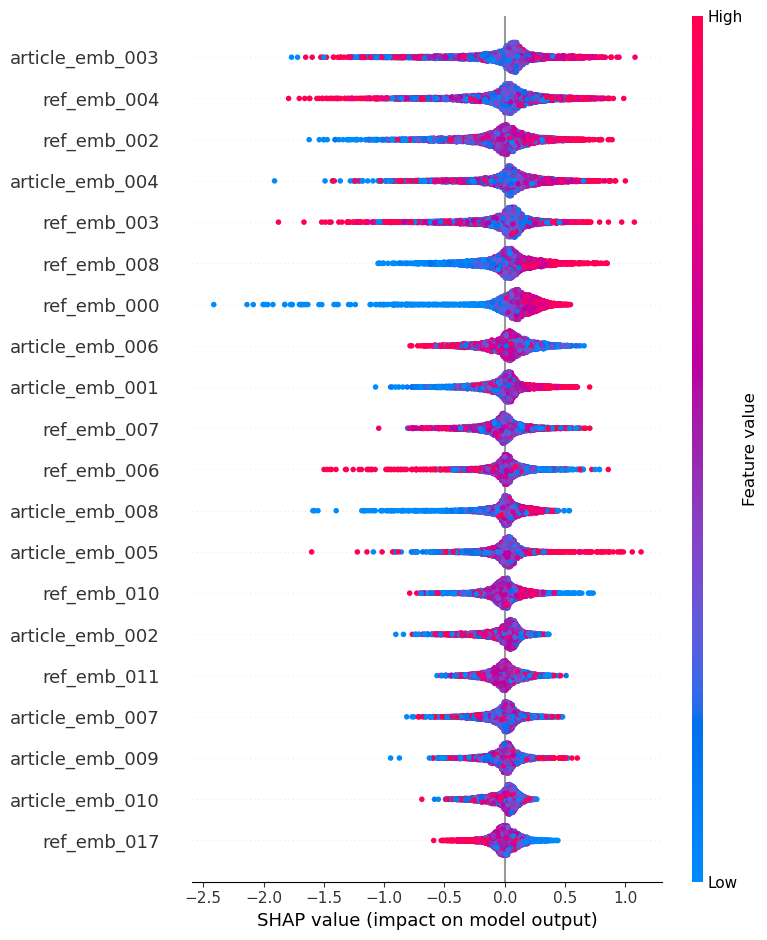

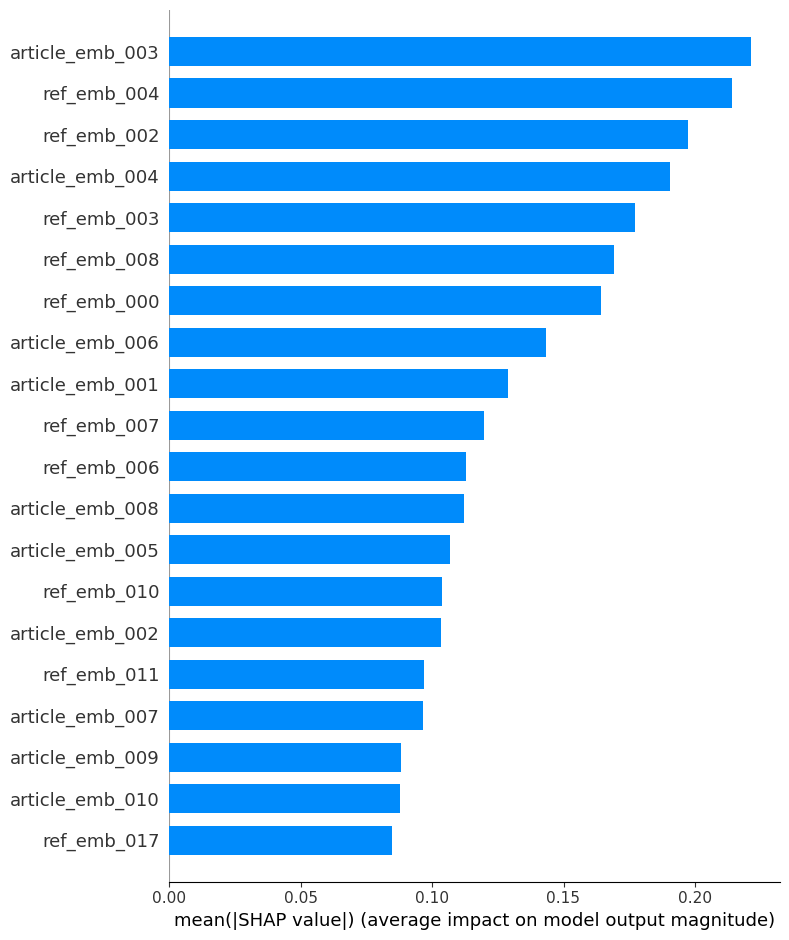

SHAP completato


In [8]:
models_64 = load_all_models(MODEL_DIRS["embedding_64"])
train64, test64 = load_textual_split(TEXTUAL_64_PATH)

run_explainability_block(
    "Embedding testuali 64",
    models_64,
    train64,
    test64,
)

## Embedding testuali 128

Secondo blocco separato per dataset e modelli basati sugli embedding testuali a 128 dimensioni.

Modelli caricati da textual_embeddings_128: 3
 - Best_KNN_textual_128_20260430_134647
 - Best_Transformer_textual_128_20260430_161040
 - Best_XGB_textual_128_20260430_152616
textual_embeddings_128.parquet: train=(2162513, 260), test=(787622, 260)


## Embedding testuali 128

Explainability per modello: Best_KNN_textual_128_20260430_134647
Feature usate: 256
Campione LIME train/test: (5000, 256), (5000, 256)
Valid reference:
LIME non riuscito: cannot import name 'display' from 'IPython.core.display' (/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/IPython/core/display.py)
SHAP saltato: il modello non e un tree model supportato da TreeExplainer.
Explainability per modello: Best_Transformer_textual_128_20260430_161040
[pair_embedding_transformer_128] Preprocessing data...
[pair_embedding_transformer_128] Preprocessing data...
Feature usate: 256
Campione LIME train/test: (5000, 256), (5000, 256)
Valid reference:


predict:   0%|          | 0/10 [00:00<?, ?it/s]

LIME non riuscito: cannot import name 'display' from 'IPython.core.display' (/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/IPython/core/display.py)
SHAP saltato: il modello non e un tree model supportato da TreeExplainer.
Explainability per modello: Best_XGB_textual_128_20260430_152616
Feature usate: 256
Campione LIME train/test: (5000, 256), (5000, 256)
Valid reference:
LIME non riuscito: cannot import name 'display' from 'IPython.core.display' (/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/IPython/core/display.py)


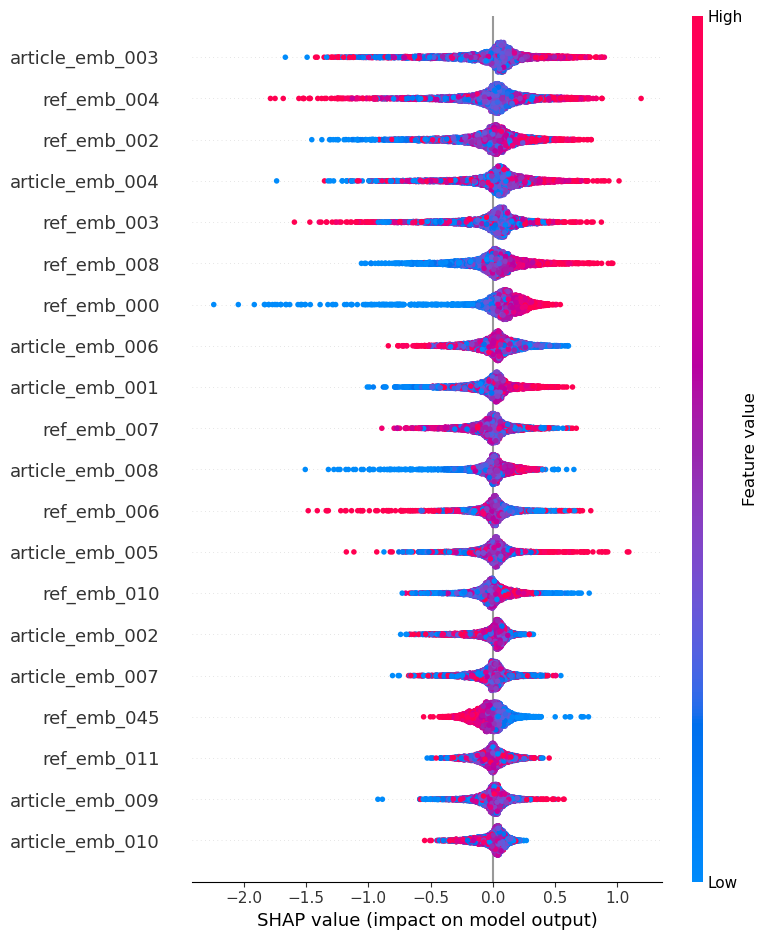

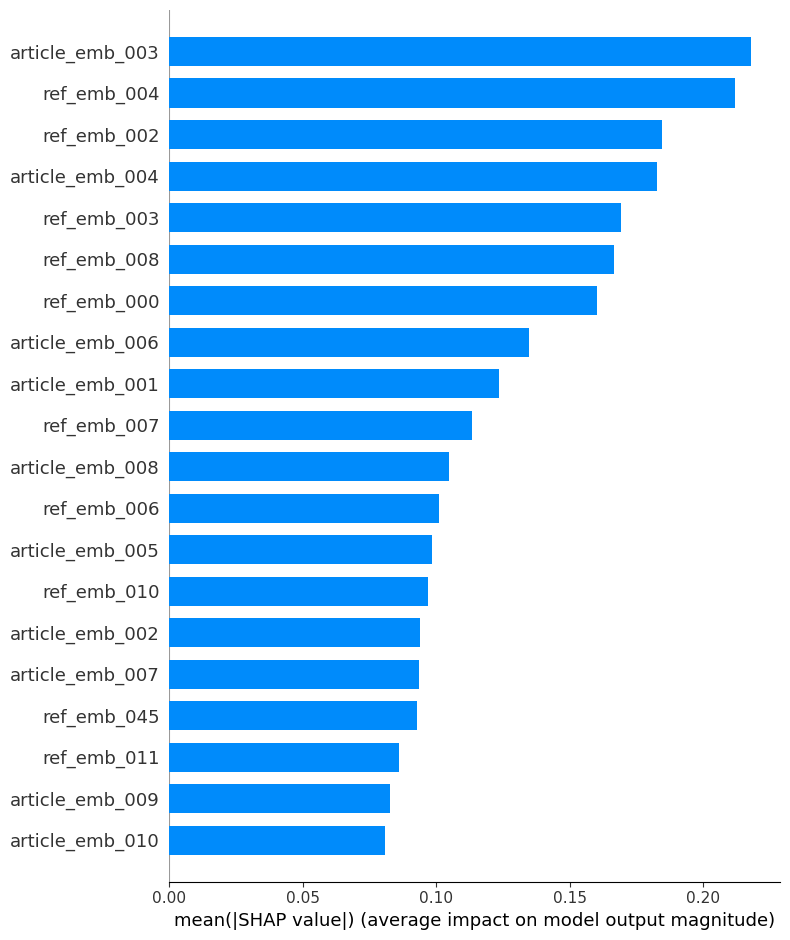

SHAP completato


In [9]:
models_128 = load_all_models(MODEL_DIRS["embedding_128"])
train128, test128 = load_textual_split(TEXTUAL_128_PATH)

run_explainability_block(
    "Embedding testuali 128",
    models_128,
    train128,
    test128,
)

## Graph features

Ultimo blocco separato per i modelli addestrati sulle feature di grafo.

Modelli caricati da graph_features: 3
 - Best_KNN_graph_based_20260430_150722
 - Best_XGB_graph_20260430_152157
 - Transformer_graph_20260430_164512
graph features: train=(2162520, 21), test=(396382, 21)


## Graph features

Explainability per modello: Best_KNN_graph_based_20260430_150722
Feature usate: 18
Campione LIME train/test: (5000, 18), (5000, 18)
Valid reference:
LIME non riuscito: cannot import name 'display' from 'IPython.core.display' (/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/IPython/core/display.py)
SHAP saltato: il modello non e un tree model supportato da TreeExplainer.
Explainability per modello: Best_XGB_graph_20260430_152157
Feature usate: 18
Campione LIME train/test: (5000, 18), (5000, 18)
Valid reference:
LIME non riuscito: cannot import name 'display' from 'IPython.core.display' (/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/IPython/core/display.py)


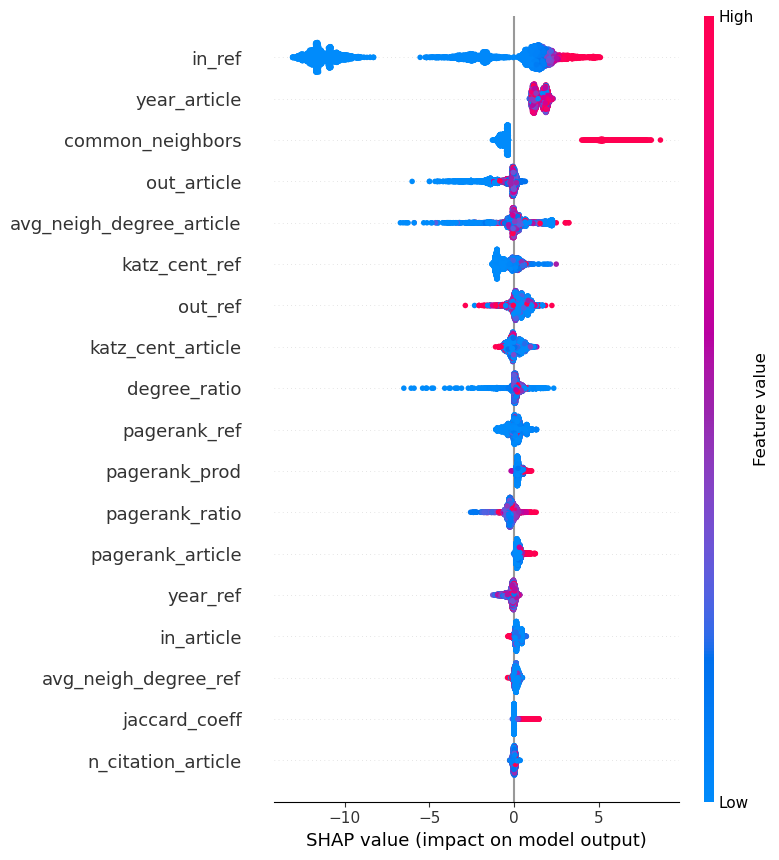

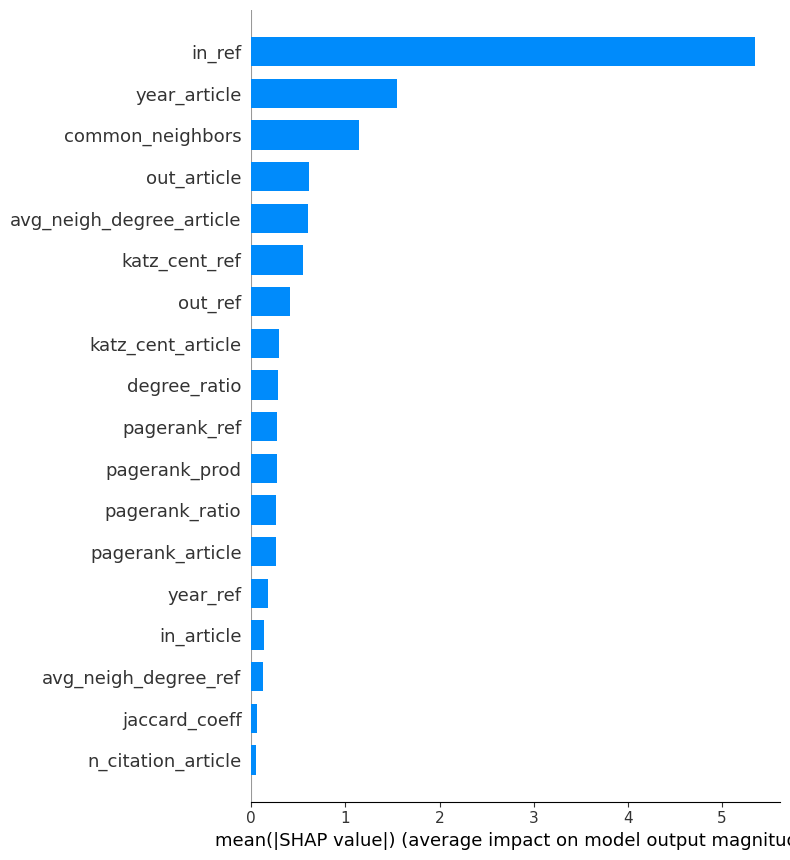

SHAP completato
Explainability per modello: Transformer_graph_20260430_164512
Feature usate: 18
Campione LIME train/test: (5000, 18), (5000, 18)
Valid reference:


predict:   0%|          | 0/10 [00:00<?, ?it/s]

LIME non riuscito: cannot import name 'display' from 'IPython.core.display' (/home/tommaso/miniconda3/envs/hack_03/lib/python3.11/site-packages/IPython/core/display.py)
SHAP saltato: il modello non e un tree model supportato da TreeExplainer.


In [10]:
models_graph = load_all_models(MODEL_DIRS["graph_features"])
train_graph, test_graph = load_graph_split(GRAPH_FEATURES_PATH)

run_explainability_block(
    "Graph features",
    models_graph,
    train_graph,
    test_graph,
)